# CS5489 - Machine Learning
# Lecture 11b - Vision Language Models (VLM)
### Dept. of Computer Science, City University of Hong Kong

# Outline
1. Tokenization
2. Visual Application
3. Vision Language Models
4. Multi-Modal Large Language Models (MLLM)
5. VLM: Prolems and Mitigations

In [33]:
# setup
%matplotlib inline
import matplotlib_inline   # setup output image format
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100  # display larger images
import matplotlib

import numpy as np
import torch
from torch import nn as nn
import torch.nn.functional as F
from torch.utils.checkpoint import checkpoint
from torchvision.transforms import Normalize, Compose, ToTensor, Resize, CenterCrop, InterpolationMode
import transformers
from transformers import pipeline, AutoProcessor, AutoModelForQuestionAnswering, CLIPProcessor, CLIPModel
import nltk  # for English tokenizer

from PIL import Image
import requests

from collections import OrderedDict
from itertools import repeat
import collections.abc
from dataclasses import dataclass
from diffusers import AutoPipelineForText2Image
import math
from typing import Tuple, Union, Callable, Optional


# Tokenization

**Image Input**: Raw image (e.g., 224×224×3 pixels)

**Patch Creation**:
- Divide image into fixed-size patches (e.g., 16×16 pixels)
- Example: 224×224 image → 196 patches (14×14 grid of 16×16 patches) 

**Patch Embedding**:
- Flatten each patch into 1D vectors
- Linear projection to embedding dimension
- Add positional embeddings to preserve spatial information

<center><img src="imgs/ViT.png" width=800></center>

In [7]:
mean = (0.48145466, 0.4578275, 0.40821073)  # OpenAI dataset mean
std = (0.26862954, 0.26130258, 0.27577711)  # OpenAI dataset std
image_size = 224

def _convert_to_rgb(image):
    return image.convert('RGB')

normalize = Normalize(mean=mean, std=std)
    
transforms = [
    Resize(image_size, interpolation=InterpolationMode.BICUBIC),
    CenterCrop(image_size),
    _convert_to_rgb,
    ToTensor(),
    normalize,
]
transforms = Compose(transforms)

In [ ]:
def _ntuple(n):
    def parse(x):
        if isinstance(x, collections.abc.Iterable):
            return x
        return tuple(repeat(x, n))
    return parse
to_2tuple = _ntuple(2)

patch_size = 16
width = 768
image_size = to_2tuple(image_size)
patch_size = to_2tuple(patch_size)

grid_size = (image_size[0] // patch_size[0], image_size[1] // patch_size[1])
conv1 = nn.Conv2d(in_channels=3, out_channels=width, kernel_size=patch_size, stride=patch_size, bias=False)

scale = width ** -0.5
class_embedding = nn.Parameter(scale * torch.randn(width))
positional_embedding = nn.Parameter(scale * torch.randn(grid_size[0] * grid_size[1] + 1, width))

img_path = "imgs/testimg.jpg" # Image of cats on a couch
raw_image = Image.open(img_path).convert('RGB')

x = transforms(raw_image).unsqueeze(0)
x = conv1(x)  # shape = [*, width, grid, grid]
print('The convolution layer is implemented for image tokenization')
x = x.reshape(x.shape[0], x.shape[1], -1)  # shape = [*, width, grid ** 2]
print('There are {} grids splitted from the image'.format(x.shape[-1]) )
x = x.permute(0, 2, 1)  # shape = [*, grid ** 2, width]
x = torch.cat(
    [class_embedding.to(x.dtype).view(1,1,-1), x], dim=1)  # shape = [*, grid ** 2 + 1, width]
x = x + positional_embedding.to(x.dtype)

print('The final size is', x.squeeze().detach().numpy().shape, 'after appending a [CLS] token')

## Absolute Position Embedding 
  - Learnable (shown in code)
  - Absolute embedding (Sinusoidal Functions of different frequencies)
  - Relative Positional Embeddings

<center><img src="imgs/posemb.png" width=600></center>

## Relative Positional Embeddings
- Apply a rotation to the word vector (angle of rotation (θ) is proportional to the word’s position in the sentence) [Reference](https://medium.com/ai-insights-cobet/rotary-positional-embeddings-a-detailed-look-and-comprehensive-understanding-4ff66a874d83)
- *Stability of Vectors*: Adding tokens at the end of a sentence doesn’t affect the vectors for words at the beginning, facilitating efficient caching.
- *Preservation of Relative Positions*: If two words, say “pig” and “dog,” maintain the same relative distance in different contexts, their vectors are rotated by the same amount. Consequently, the dot product between these vectors, remains constant


<center><img src="imgs/RoPE.png" width=600></center>

# Visual Application
- Visual Understanding
    - Recognition
    - Detection
    - Segmentation
- Multi-Modal Visual Understanding
    - Visual Question Answering
    - Captioning

## Region-Based CNN (RCNN / R-CNN)

R-CNN first proposes RoIs with a search algorithm, then extracts features with CNN, and then classifies those regions based on their features. ROI stands for Region Of Interest, which is literally where we are interested. It refers to places where the object may be in the input image.

<center><img src="imgs/det-rcnn.jpg" width=600></center>

- *Extract region proposals*: These regions have a high probability of containing an object. A selective search algorithm scans the input image to find regions, and proposes them as RoI to be processed by the next modules. The proposed RoIs are then warped to have a fixed size because they usually vary in size, but CNN requires a fixed input image size.
- *Feature extraction module* : A pretrained convolutional network is run to extract features from each ROI.
- *Classification module* : A classifier like SVM is used to classify candidate detections. SVM determines whether the region is an object or not and, if so, what kind of object it is. This is based on the extracted features from the previous step.
- *Localization module* : The location and size of the bounding box that surrounds the object are predicted. The bounding box is represented by identifying four values: the x and y coordinates of the box’s origin (x, y), the width, and the height of the box (w, h). Putting this together, the regressor predicts the four real-valued numbers that define the bounding box as the following tuple: (x, y, w, h).

## Fast R-CNN

Fast R-CNN produces region proposals based on the last feature map of CNN, not from the original input image like R-CNN. In other words, Fast R-CNN implements CNN first and then generates region proposals. On the contrary, R-CNN produces region proposals first and then implements CNN.

<center><img src="imgs/det-fast-rcnn.jpg" width=600></center>

## Faster R-CNN

The architecture of Faster R-CNN can be described using two main networks, Region proposal network (RPN) and Fast R-CNN. 

The output is then passed into two fully connected layers. One for the object classifier and one for the bounding box coordinate predictions to obtain our final localizations. This architecture achieves an end-to-end trainable, complete object detection pipeline where all of the required components are inside the network

<center><img src="imgs/det-faster-rcnn.jpg" width=600></center>

## Region Proposal Network (RPN)

RPN has a classifier and a regressor. 
- Anchor is the central point of the sliding window.
- Classifier determines the probability of a proposal having the target object.
- Regression regresses the coordinates of the proposals. For any image, scale and aspect-ratio (i.e., width of image/height of image) 

For each pixel (anchor), 3 scale and 3 aspect-ratio are selected (k=9). Then, for the whole image, number of anchors is W*H*K.

<center><img src="imgs/det-rpn.jpg" width=600></center>

## You Only Look Once (YOLO)

YOLO [reference](https://arxiv.org/pdf/1506.02640) is based on the idea of segmenting an image into smaller images. The cell in which the center of an object, for instance, the center of the dog, resides, is the cell responsible for detecting that object. 
- Each cell will predict B bounding boxes and a confidence score for each box. 
- While each cell may predict any number of bounding boxes and confidence scores for those boxes, it only predicts one class.
    - This is a limitation of the YOLO algorithm itself, and if there are multiple objects of different classes in one grid cell, the algorithm will fail to classify both correctly.
- Each prediction from a grid cell will be of shape C + B * 5
    - C is the number of classes and B is the number of predicted bounding boxes
    - B is multiplied by 5 here because it includes (x, y, w, h, confidence) for each box.
    - Because there are S × S grid cells in each image, the overall prediction of the model is a tensor of shape S × S × (C + B ∗ 5).

<center><img src="imgs/det-yolo.jpg" width=600></center>

## DEtection TRansformer (DETR)

*Transformer Encoder-Decoder*: 
- The encoder takes the features from the backbone and, using self-attention, models the relationships between all parts of the image to create global, context-aware features.
- The decoder takes a fixed number of learned object queries and attends to the encoded image features. Each object query is designed to focus on a potential object in the image and output an embedding for it.

*Prediction Feed-Forward Network (FFN)*: This is a simple feed-forward network that takes each output embedding from the decoder and makes the final prediction: a class label and a bounding box (relative to the entire image, not an anchor).

*Bipartite Matching* [(Link)](https://math.mit.edu/~goemans/18433S09/matching-notes.pdf):
- The Hungarian algorithm is used to find this matching by minimizing the total cost, which combines both the classification error and the bounding box difference.
- After finding the best match, a standard loss (like cross-entropy for classification and a combination of L1 and generalized IoU loss for boxes) is computed only on these matched pairs. This forces the model to learn to make unique predictions for each object.

<center><img src="imgs/det-detr.jpg" width=900></center>

## Segmentation

- Semantic, i.e., "What is this pixel?"
- Instance, i.e., "Which object is this pixel?"
- Panoptic, i.e., "What is this pixel AND which object?"


<center><img src="imgs/det-segment.jpg" width=600></center>

## Multi-Modal Understanding

- Vision question answering (VQA): having a machine answer a natural language question about an image.
    - VQA is typically framed as a classification task over a predefined answer vocabulary
    - P(answer | image, question) = softmax(W * f(image, question))
    - Challenges
      - Language Priors: Models can learn to answer based on question patterns without looking at the image. For example, "What color is the banana?" -> "Yellow" (without checking image)
      - Compositional Reasoning: Understanding complex questions requiring multiple reasoning steps: "Is the person holding the umbrella because it's raining?"
      - Grounding: Ensuring answers are actually grounded in the visual content rather than guessing.


<center><img src="imgs/det-vqa.jpg" width=600></center> 

- Zero-shot learning: A machine learning paradigm where a model can recognize and classify objects it has never seen during training.
    - Seen Classes (S): Classes available during training
    - Unseen Classes (U): Classes only encountered during testing
    - Attribute Space: Shared semantic representation
    - Embedding Functions: Map between visual and semantic spaces (A shared space where both seen and unseen classes can be represented using attributes, word vectors, or text descriptions.)
<center><img src="imgs/det-zero.png" width=600></center> 
  
- Open-vocabulary detection: detect and classify objects from any category described in natural language, including categories never seen during training.
<center><img src="imgs/det-open.jpg" width=400></center> 


# Vision Language Models

## Contrastive Language-Image Pre-training (CLIP)

CLIP learns visual concepts from natural language supervision by training on millions or billions image-text pairs from the internet (two-tower design)
- Image encoder: Vision Transformer (ViT) or ResNet
- Text encoder: Transformer
- Output: Normalized embeddings in shared space, and compute cosine similarities between all image-text pairs
- Batch processing and Contrastive loss:
    - Maximize similarity for matching pairs
    - Minimize similarity for non-matching pairs in the same batch
    - Symmetric loss: Applied in both directions (image→text and text→image)
  
<center><img src="imgs/CLIP.png" width=800></center> 

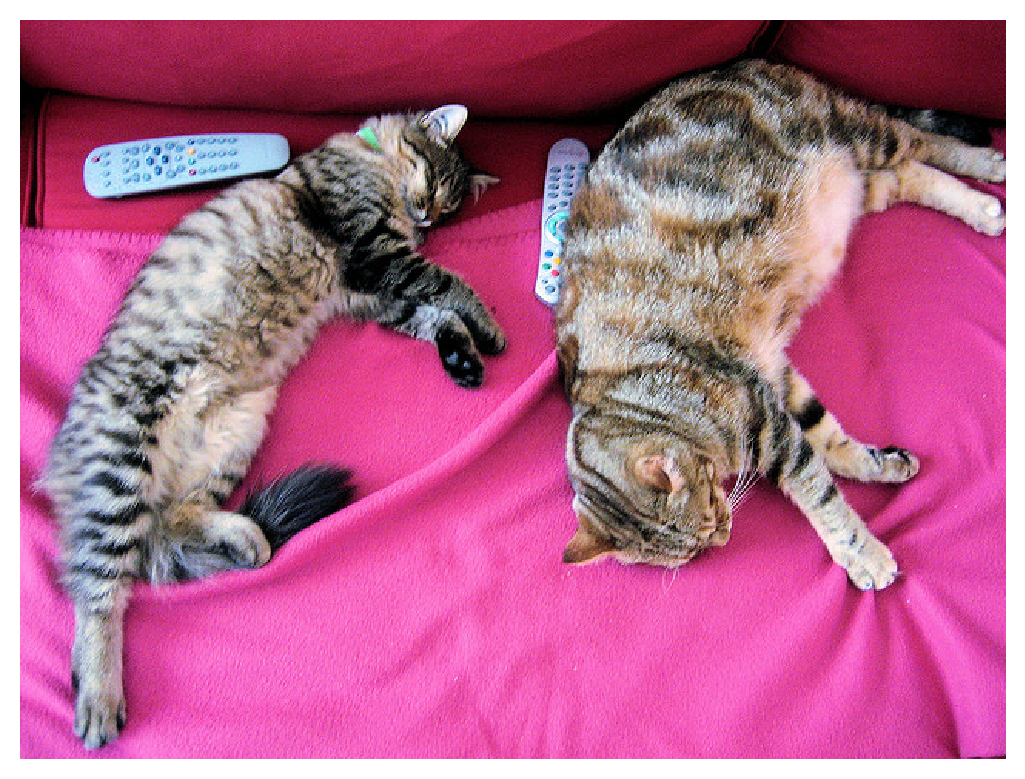

In [35]:
from PIL import Image
import requests

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Open image from URL
img_path = "imgs/testimg.jpg" # Image of cats on a couch
raw_image = Image.open(img_path).convert('RGB')
plt.imshow(raw_image, interpolation='nearest')  
plt.gca().set_axis_off()
plt.show()

inputs = processor(text=["a photo of a cat", "a photo of a dog"], images=raw_image, return_tensors="pt", padding=True)

outputs = model(**inputs)
logits_per_image = outputs.logits_per_image # this is the image-text similarity score
probs = logits_per_image.softmax(dim=1) 

In [48]:
print(outputs.keys())
print('Text Embedding', outputs.text_embeds.shape)
print('Image Embedding', outputs.image_embeds.shape)

print(probs[0].detach().cpu().numpy())
ind = probs[0].argmax()
print(["a photo of a cat", "a photo of a dog"][ind.item()])

odict_keys(['logits_per_image', 'logits_per_text', 'text_embeds', 'image_embeds', 'text_model_output', 'vision_model_output'])
Text Embedding torch.Size([2, 512])
Image Embedding torch.Size([1, 512])
[0.994858   0.00514195]
a photo of a cat


## Grounded Language-Image Pre-training (GLIP)

Grounded Language-Image Pre-training (GLIP) is a model that unifies object detection and language understanding. It learns by aligning regions in an image with words or phrases in a text caption, allowing it to perform tasks like zero-shot object detection based on any text prompt

<center><img src="imgs/det-glip.png" width=900></center> 

## Vision Question Answering


In [49]:
# Define Model and Device (use "cuda" if GPU is available, otherwise "cpu")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_ID = "Salesforce/blip-vqa-base"

# Example Image URL and Question
question_text = "how many cats are in the picture?"

vqa_pipeline = pipeline(
    task="visual-question-answering",
    model=MODEL_ID,
    device=0 if DEVICE == "cuda" else -1 # Use GPU 0 or CPU -1
)

# Execute inference
# Output is a list of dictionaries [{'score':..., 'answer': '...'}]
pipeline_output = vqa_pipeline(image=raw_image, question=question_text)
print('Question:', question_text)
print(f"Final Answer: {pipeline_output[0]['answer']}")

Device set to use cpu


Question: how many cats are in the picture?
Final Answer: 2


Loading pipeline components...:   0%|                                                                                                                                                                                          | 0/7 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
`torch_dtype` is deprecated! Use `dtype` instead!
Loading pipeline components...: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 28.85it/s]


Starting image generation for prompt: 'Astronaut riding a neon space horse, detailed digital art, 8k'
Using Seed: 42, Guidance Scale: 7.5, Steps: 30


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [01:30<00:00,  3.01s/it]


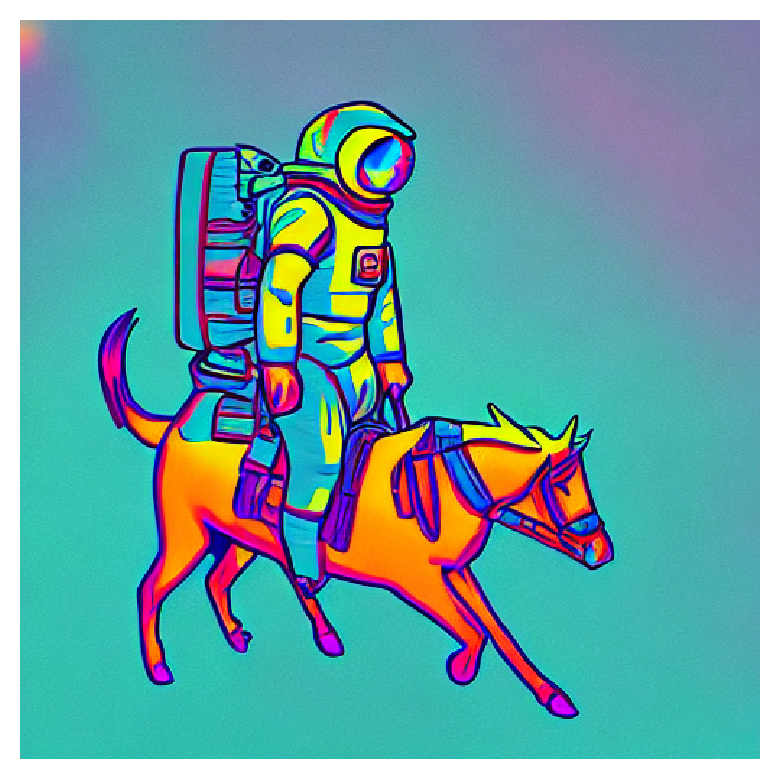

In [32]:
MODEL_ID = "runwayml/stable-diffusion-v1-5"

# Load the pipeline, moving components (Text Encoder, U-Net, VAE) to the selected device
pipeline = AutoPipelineForText2Image.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
).to(DEVICE)

# Define the text prompt
prompt = "Astronaut riding a neon space horse, detailed digital art, 8k"

# Define Generation Parameters for reproducibility and quality control
SEED = 42
GUIDANCE_SCALE = 7.5
INFERENCE_STEPS = 30

# Initialize the Generator for reproducible results 
generator = torch.Generator(device=DEVICE).manual_seed(SEED)

# Execute Inference
print(f"Starting image generation for prompt: '{prompt}'")
print(f"Using Seed: {SEED}, Guidance Scale: {GUIDANCE_SCALE}, Steps: {INFERENCE_STEPS}")

# The pipeline executes the full LDM flow: Text Encoding -> Latent Initialization -> 
# Iterative U-Net Denoising -> VAE Decoding [24]
output = pipeline(
    prompt=prompt,
    num_inference_steps=INFERENCE_STEPS,
    guidance_scale=GUIDANCE_SCALE,
    generator=generator,
)

# The output is a list containing the PIL Image object
generated_image = output.images[0]
plt.imshow(generated_image, interpolation='nearest')  
plt.gca().set_axis_off()
plt.show()

## Bias and Ethics Issues
- Bias Issues: Stereotypes, Representational Bias, Algorithmic Discrimination, Toxic and Harmful Content
- Ethics Issues: Privacy Concerns, Intellectual Property and Copyright, Job Displacement, Environmental Impact
- We need to carefully think more ...

# Multi-Modal Large Language Models (MLLM)

*Standard Cross-Attention based Deep Fusion*: The input modalities are deeply fused into the internal layers of the LLM using standard cross-attention layer. The cross-attention can be added either before or after the self-attention layer
<center><img src="imgs/mllm-1.jpg" width=600></center>

*Custom Layer based Deep Fusion (CLDF)*: The input modalities are deeply fused into the internal layers of the LLM using custom-designed layers. Custom cross-attention layers or other custom layers are used for modality fusion.
<center><img src="imgs/mllm-2.jpg" width=600></center>

*Non-Tokenized Early Fusion (NTEF)*: The (non-tokenized) input modalities are directly fed to the model at its input, rather than to its internal layers, resulting in early fusion. Different types of modules are used to connect modality encoder outputs to the LLM (model) like
- a LinearLayer/MLP,
- Q-former and a Linear-Layer/MLP
- Perceiver resampler
- Custom learnable layers
<center><img src="imgs/mllm-3.jpg" width=600></center>

*TokenizedEarlyFusion(TEF)*: The tokenized input modalities are directly fed into the model at its input. Either a decoder-only transformer or an encoder-decoder style transformer is used a the multimodal transformer in this architecture.
<center><img src="imgs/mllm-4.jpg" width=600></center>

# VLMs: Applications and Future
- Applications:
    - multi-modal Chatbot
    - GUI-agent, embodied AI (robots), spatial intelligence  etc
- Main research questions:
    - How can VLMs achieve better compositional reasoning and reduce object hallucination?
    - How to efficiently scale VLMs while maintaining performance on specialized domains?
    - How can VLMs effectively handle video, i.e., spatial-temporal understanding?
    - How can VLM facilitate robot learning and embodied AI design.

### Reference
- https://github.com/m-peker/visionbridge-vlm
- https://huggingface.co/blog/vlms-2025
- https://medium.com/@msapeker/building-vision-language-models-from-scratch-a-practitioners-guide-b092a29105cf